# Explainable AI for Stacking Meta-Learners (SHAP + LIME)

This notebook explains the meta-learner (MLP, BiLSTM, LinearSVC) using SHAP and LIME. The meta-learner receives only a 16-dimensional vector (12 soft probabilities + 4 entropy values) from the four base models. It does not see the original Turkish text.

## What you will learn

- How to load trained stacking meta-models and cached meta-features.
- How to compute SHAP explanations for all three classes.
- How to inspect local explanations with force/waterfall plots.
- How to compare SHAP with LIME for individual examples.
- How to summarize class-wise behavior, especially for contradiction.


## How to interpret SHAP plots (quick guide)

- **Summary (beeswarm) plot**: shows global feature impact for one class across many examples.
  - Features at top are generally more important.
  - Red means higher feature value, blue means lower.
  - Position on x-axis shows positive/negative impact on class score.
- **Bar plot**: mean absolute SHAP value per feature (global importance magnitude).
- **Force/Waterfall plot**: local explanation for a single example.
  - Positive contributions push prediction toward a class.
  - Negative contributions pull prediction away from that class.


In [1]:
from google.colab import files

# Upload files from your local system
uploaded = files.upload()

for fn in uploaded.keys():
  print('User uploaded file "{name}" with length {length} bytes'.format(
      name=fn, length=len(uploaded[fn])))


Saving stacking_cache_train_split_16feat_entropy.zip to stacking_cache_train_split_16feat_entropy.zip
User uploaded file "stacking_cache_train_split_16feat_entropy.zip" with length 39007374 bytes


In [2]:
from google.colab import files

# Upload files from your local system
uploaded = files.upload()

for fn in uploaded.keys():
  print('User uploaded file "{name}" with length {length} bytes'.format(
      name=fn, length=len(uploaded[fn])))


Saving stacking_artifacts_16feat.zip to stacking_artifacts_16feat.zip
User uploaded file "stacking_artifacts_16feat.zip" with length 863248 bytes


In [3]:
# Replace 'your_zip_file.zip' with the actual name of your uploaded zip file.
# The files will be extracted to the current working directory (/content/).
!unzip -q /content/stacking_cache_train_split_16feat_entropy.zip -d /content/
!unzip -q /content/stacking_artifacts_16feat.zip -d /content/
print("To unzip your file, uncomment the line above and replace 'your_zip_file.zip' with the actual filename.")
print("For example: !unzip -q /content/stacking_cache_train_split_16feat_entropy.zip -d /content/")

To unzip your file, uncomment the line above and replace 'your_zip_file.zip' with the actual filename.
For example: !unzip -q /content/stacking_cache_train_split_16feat_entropy.zip -d /content/


In [4]:
from huggingface_hub import login
login(token=os.environ.get("HF_TOKEN"))

In [5]:
# If needed in Colab, uncomment and run:
!pip -q install shap lime datasets huggingface_hub seaborn scikit-learn joblib

import gc
import random
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import shap
import torch
import torch.nn as nn
from datasets import load_dataset
from IPython.display import Markdown, display
from lime.lime_tabular import LimeTabularExplainer
from scipy.special import softmax
from sklearn.metrics import accuracy_score, f1_score

sns.set_style("whitegrid")


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 11.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


In [6]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = "cuda"
print("Device:", DEVICE)

# Runtime knobs (T4-friendly)
N_BACKGROUND = 800
N_EXPLAIN = 200
N_EXPLAIN_SVM_BILSTM = 120
KERNEL_NSAMPLES_MLP = 120
KERNEL_NSAMPLES_OTHER = 80

SAVE_DPI = 300
PLOTS_DIR = Path("xai_plots")
PLOTS_DIR.mkdir(exist_ok=True, parents=True)
print("Saving plots to:", PLOTS_DIR.resolve())

MODEL_ORDER = ["bert", "mdeberta", "gemma", "qwen"]
LABEL_NAMES = ["entailment", "neutral", "contradiction"]
NUM_LABELS = 3
FEATURE_NAMES = [
    "bert_p0", "bert_p1", "bert_p2",
    "mdeberta_p0", "mdeberta_p1", "mdeberta_p2",
    "gemma_p0", "gemma_p1", "gemma_p2",
    "qwen_p0", "qwen_p1", "qwen_p2",
    "entropy_bert", "entropy_mdeberta", "entropy_gemma", "entropy_qwen",
]

CHOSEN_CONFIG = "trglue_mnli"
EVAL_SPLIT = "test_matched"


Device: cuda
Saving plots to: /content/xai_plots


In [7]:
WORKDIR = Path(".")
PRIMARY_MODEL_DIR = WORKDIR / "stacking_artifacts" / "trained_models"
FALLBACK_MODEL_DIR = WORKDIR / "stacking_artifacts_16feat" / "trained_models"

if PRIMARY_MODEL_DIR.exists():
    TRAINED_MODELS_DIR = PRIMARY_MODEL_DIR
elif FALLBACK_MODEL_DIR.exists():
    TRAINED_MODELS_DIR = FALLBACK_MODEL_DIR
else:
    raise FileNotFoundError(
        f"Could not find trained_models folder. Checked:\n"
        f"- {PRIMARY_MODEL_DIR.resolve()}\n"
        f"- {FALLBACK_MODEL_DIR.resolve()}"
    )

CACHE_DIR = WORKDIR / "stacking_cache_train_split_16feat_entropy"
assert CACHE_DIR.exists(), f"Missing cache folder: {CACHE_DIR.resolve()}"

print("Using trained models from:", TRAINED_MODELS_DIR.resolve())
print("Using cache from:", CACHE_DIR.resolve())


Using trained models from: /content/stacking_artifacts_16feat/trained_models
Using cache from: /content/stacking_cache_train_split_16feat_entropy


In [8]:
def compute_entropy(probs: np.ndarray) -> np.ndarray:
    probs = np.clip(probs, 1e-10, 1.0)
    return -np.sum(probs * np.log(probs), axis=1)


def cache_name(config: str, split: str, model_key: str) -> Path:
    safe_cfg = config.replace("/", "_")
    safe_sp = split.replace("/", "_")
    return CACHE_DIR / f"{safe_cfg}__{safe_sp}__{model_key}_probs.npy"


def load_probs_from_cache(config: str, split: str) -> dict:
    probs = {}
    for model_key in MODEL_ORDER:
        p = cache_name(config, split, model_key)
        if not p.exists():
            raise FileNotFoundError(f"Missing cache file: {p}")
        probs[model_key] = np.load(p)
    return probs


def build_X16(probs_dict: dict) -> np.ndarray:
    bert_p = probs_dict["bert"]
    mdeb_p = probs_dict["mdeberta"]
    gemma_p = probs_dict["gemma"]
    qwen_p = probs_dict["qwen"]
    return np.hstack([
        bert_p,
        mdeb_p,
        gemma_p,
        qwen_p,
        compute_entropy(bert_p).reshape(-1, 1),
        compute_entropy(mdeb_p).reshape(-1, 1),
        compute_entropy(gemma_p).reshape(-1, 1),
        compute_entropy(qwen_p).reshape(-1, 1),
    ]).astype(np.float32)


In [9]:
class StackingMLP(nn.Module):
    def __init__(self, in_dim=16, n_classes=3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, 64), nn.BatchNorm1d(64), nn.ReLU(), nn.Dropout(0.2),
            nn.Linear(64, 32), nn.BatchNorm1d(32), nn.ReLU(), nn.Dropout(0.2),
            nn.Linear(32, n_classes),
        )

    def forward(self, x):
        return self.net(x)


class StackingBiLSTM(nn.Module):
    def __init__(self, hidden_size=64, n_classes=3):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=4,
            hidden_size=hidden_size,
            num_layers=1,
            batch_first=True,
            bidirectional=True,
        )
        self.drop = nn.Dropout(0.2)
        self.fc = nn.Linear(hidden_size * 2, n_classes)

    def forward(self, x):
        probs = x[:, :12].view(x.size(0), 4, 3)
        ents = x[:, 12:].unsqueeze(-1)
        seq = torch.cat([probs, ents], dim=-1)
        out, _ = self.lstm(seq)
        return self.fc(self.drop(out[:, -1, :]))


In [10]:
def load_meta_artifacts(cfg: str):
    scaler_path = TRAINED_MODELS_DIR / f"{cfg}_scaler.joblib"
    svm_path = TRAINED_MODELS_DIR / f"{cfg}_svm.joblib"
    mlp_path = TRAINED_MODELS_DIR / f"{cfg}_mlp.pt"
    bilstm_path = TRAINED_MODELS_DIR / f"{cfg}_bilstm.pt"

    for pp in [scaler_path, svm_path, mlp_path, bilstm_path]:
        if not pp.exists():
            raise FileNotFoundError(f"Missing model artifact: {pp}")

    scaler = joblib.load(scaler_path)
    svm = joblib.load(svm_path)

    mlp = StackingMLP(in_dim=16, n_classes=NUM_LABELS)
    mlp.load_state_dict(torch.load(mlp_path, map_location="cpu"))
    mlp.eval()

    bilstm = StackingBiLSTM(hidden_size=64, n_classes=NUM_LABELS)
    bilstm.load_state_dict(torch.load(bilstm_path, map_location="cpu"))
    bilstm.eval()

    return scaler, mlp, bilstm, svm


scaler, mlp_model, bilstm_model, svm_model = load_meta_artifacts(CHOSEN_CONFIG)
print("Loaded scaler + MLP + BiLSTM + LinearSVC")


Loaded scaler + MLP + BiLSTM + LinearSVC


In [11]:
DATASET_NAME = "yilmazzey/sdp2-nli"

datasets_hf = {
    "snli_tr_1_1": load_dataset(DATASET_NAME, "snli_tr_1_1"),
    "multinli_tr_1_1": load_dataset(DATASET_NAME, "multinli_tr_1_1"),
    "trglue_mnli": load_dataset(DATASET_NAME, "trglue_mnli"),
}

train_probs = load_probs_from_cache(CHOSEN_CONFIG, "train")
X_train = build_X16(train_probs)
y_train = np.array(datasets_hf[CHOSEN_CONFIG]["train"]["label"], dtype=np.int64)

if EVAL_SPLIT not in datasets_hf[CHOSEN_CONFIG]:
    raise ValueError(f"Split not found: {EVAL_SPLIT}")

eval_probs = load_probs_from_cache(CHOSEN_CONFIG, EVAL_SPLIT)
X_eval = build_X16(eval_probs)
y_eval = np.array(datasets_hf[CHOSEN_CONFIG][EVAL_SPLIT]["label"], dtype=np.int64)

X_train_s = scaler.transform(X_train).astype(np.float32)
X_eval_s = scaler.transform(X_eval).astype(np.float32)

X_bg = X_train_s[: min(N_BACKGROUND, len(X_train_s))]
X_exp = X_eval_s[: min(N_EXPLAIN, len(X_eval_s))]
y_exp = y_eval[: len(X_exp)]

print("X_train_s:", X_train_s.shape)
print("X_eval_s:", X_eval_s.shape)
print("X_bg:", X_bg.shape)
print("X_exp:", X_exp.shape)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

snli_tr_1_1/train-00000-of-00001.parquet:   0%|          | 0.00/25.4M [00:00<?, ?B/s]

snli_tr_1_1/validation-00000-of-00001.pa(…):   0%|          | 0.00/558k [00:00<?, ?B/s]

snli_tr_1_1/test-00000-of-00001.parquet:   0%|          | 0.00/557k [00:00<?, ?B/s]

...

Generating validation_matched split:   0%|          | 0/9050 [00:00<?, ? examples/s]

Generating validation_mismatched split:   0%|          | 0/9200 [00:00<?, ? examples/s]

Generating test_matched split:   0%|          | 0/9008 [00:00<?, ? examples/s]

Generating test_mismatched split:   0%|          | 0/9217 [00:00<?, ? examples/s]

X_train_s: (162788, 16)
X_eval_s: (9008, 16)
X_bg: (800, 16)
X_exp: (200, 16)


In [12]:
def torch_softmax_logits(model: nn.Module, X_np: np.ndarray) -> np.ndarray:
    model.eval()
    with torch.no_grad():
        X_t = torch.tensor(X_np, dtype=torch.float32)
        logits = model(X_t)
        probs = torch.softmax(logits, dim=-1).cpu().numpy()
    return probs


def svm_predict_proba_like(clf, X_np: np.ndarray) -> np.ndarray:
    scores = clf.decision_function(X_np)
    return softmax(scores, axis=1)


def predict_mlp_proba(X_np: np.ndarray) -> np.ndarray:
    return torch_softmax_logits(mlp_model, X_np)


def predict_bilstm_proba(X_np: np.ndarray) -> np.ndarray:
    return torch_softmax_logits(bilstm_model, X_np)


def predict_svm_proba(X_np: np.ndarray) -> np.ndarray:
    return svm_predict_proba_like(svm_model, X_np)


In [13]:
p_mlp = predict_mlp_proba(X_exp)
p_bilstm = predict_bilstm_proba(X_exp)
p_svm = predict_svm_proba(X_exp)

pred_mlp = p_mlp.argmax(axis=1)
pred_bilstm = p_bilstm.argmax(axis=1)
pred_svm = p_svm.argmax(axis=1)

for name, pred in [("MLP", pred_mlp), ("BiLSTM", pred_bilstm), ("LinearSVC", pred_svm)]:
    acc = accuracy_score(y_exp, pred)
    f1m = f1_score(y_exp, pred, average="macro", zero_division=0)
    print(f"{name:<10} | acc={acc:.4f} | macroF1={f1m:.4f}")


MLP        | acc=0.8600 | macroF1=0.8586
BiLSTM     | acc=0.8650 | macroF1=0.8638
LinearSVC  | acc=0.8550 | macroF1=0.8538


## SHAP Analysis (All 3 classes)

We run model-agnostic SHAP (`KernelExplainer`) and loop over all classes:
- entailment (0)
- neutral (1)
- contradiction (2)

For each class, we save:
1. Summary (beeswarm) plot
2. Bar plot (global importance)

All figures are saved to `xai_plots/` at 300 dpi.


In [14]:
X_bg_kernel = shap.kmeans(X_bg, min(80, len(X_bg)))
print("Prepared SHAP kmeans background")


Prepared SHAP kmeans background


In [15]:
def run_shap_multiclass(model_name, predict_fn, X_background, X_to_explain, nsamples):
    print("\n" + "=" * 90)
    print(f"Running SHAP for {model_name}")

    explainer = shap.KernelExplainer(predict_fn, X_background)
    shap_values = explainer.shap_values(X_to_explain, nsamples=nsamples)

    for class_idx in range(NUM_LABELS):
        class_name = LABEL_NAMES[class_idx]
        sv = shap_values[class_idx] if isinstance(shap_values, list) else shap_values[:, :, class_idx]

        plt.figure(figsize=(10, 6))
        shap.summary_plot(sv, X_to_explain, feature_names=FEATURE_NAMES, show=False, plot_type="dot")
        plt.title(f"{model_name} - SHAP Summary - {class_name}")
        plt.tight_layout()
        out_summary = PLOTS_DIR / f"{model_name.lower()}_summary_{class_name}.png"
        plt.savefig(out_summary, dpi=SAVE_DPI, bbox_inches="tight")
        plt.show()

        mean_abs = np.abs(sv).mean(axis=0)
        bar_df = pd.DataFrame({"feature": FEATURE_NAMES, "mean_abs_shap": mean_abs}).sort_values("mean_abs_shap", ascending=False)

        plt.figure(figsize=(9, 6))
        plt.barh(bar_df["feature"][::-1], bar_df["mean_abs_shap"][::-1])
        plt.xlabel("Mean |SHAP value|")
        plt.title(f"{model_name} - SHAP Bar Importance - {class_name}")
        plt.tight_layout()
        out_bar = PLOTS_DIR / f"{model_name.lower()}_bar_{class_name}.png"
        plt.savefig(out_bar, dpi=SAVE_DPI, bbox_inches="tight")
        plt.show()

        note = (
            f"**{model_name} / {class_name}:** Top rows/bars indicate the features most influential for this class. "
            f"For contradiction, inspect whether qwen/gemma probabilities and entropy features dominate."
        )
        display(Markdown(note))

    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    gc.collect()

    return explainer, shap_values



Running SHAP for MLP


  0%|          | 0/200 [00:00<?, ?it/s]

/tmp/ipykernel_1588/768332465.py:13: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(sv, X_to_explain, feature_names=FEATURE_NAMES, show=False, plot_type="dot")


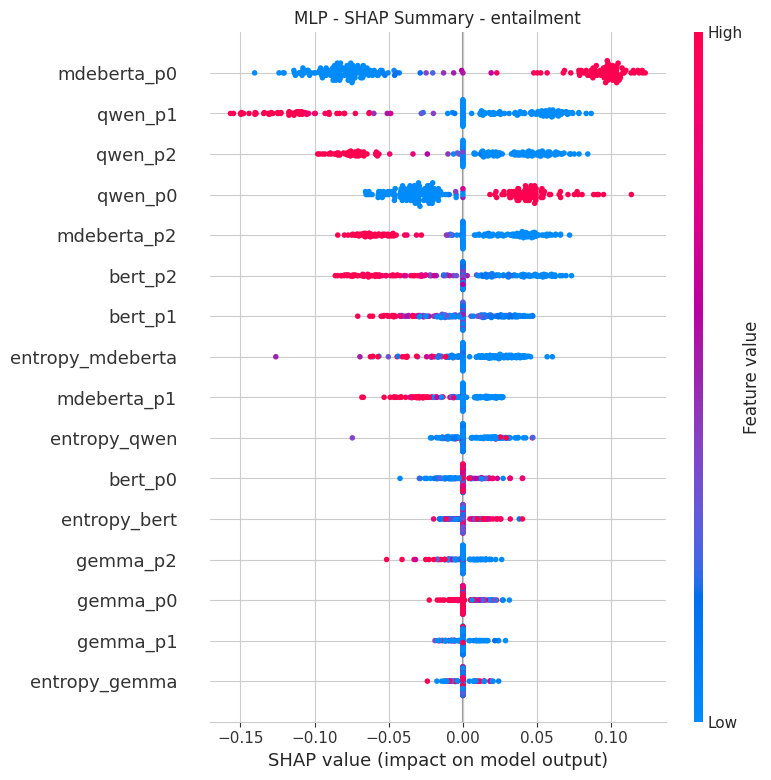

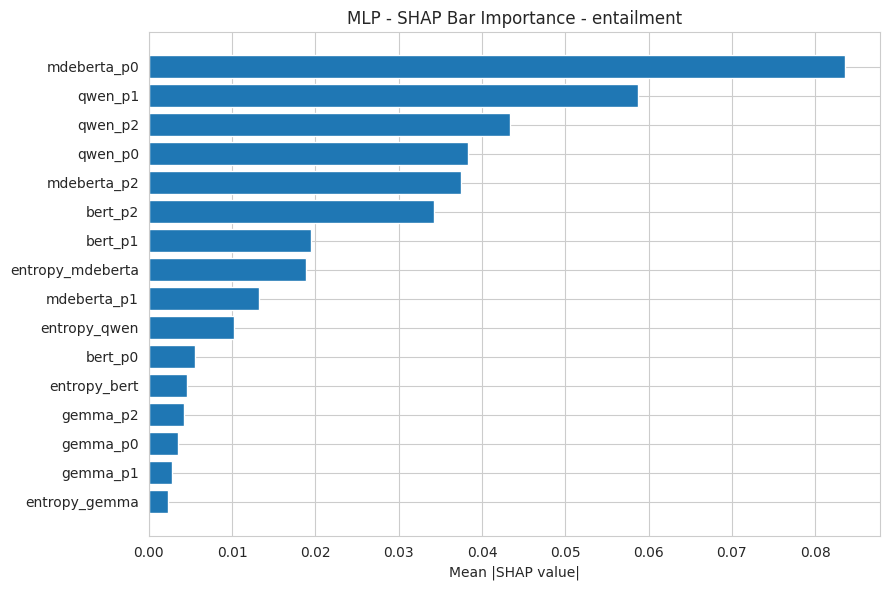

**MLP / entailment:** Top rows/bars indicate the features most influential for this class. For contradiction, inspect whether qwen/gemma probabilities and entropy features dominate.

/tmp/ipykernel_1588/768332465.py:13: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(sv, X_to_explain, feature_names=FEATURE_NAMES, show=False, plot_type="dot")


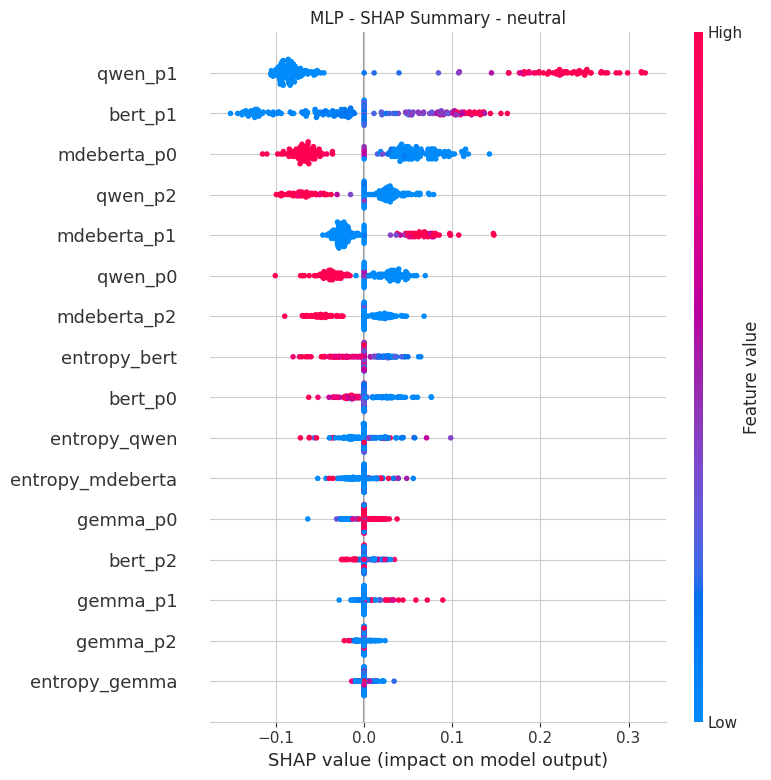

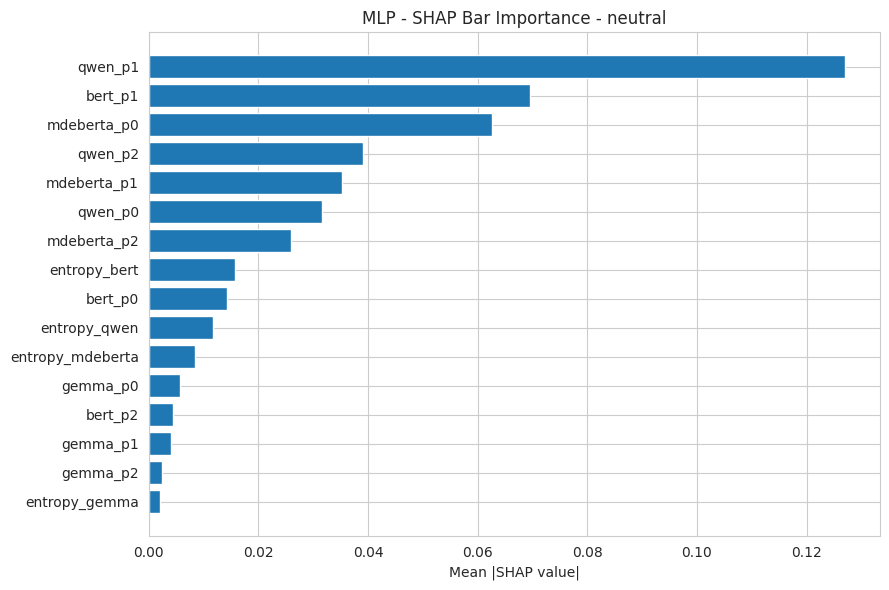

**MLP / neutral:** Top rows/bars indicate the features most influential for this class. For contradiction, inspect whether qwen/gemma probabilities and entropy features dominate.

/tmp/ipykernel_1588/768332465.py:13: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(sv, X_to_explain, feature_names=FEATURE_NAMES, show=False, plot_type="dot")


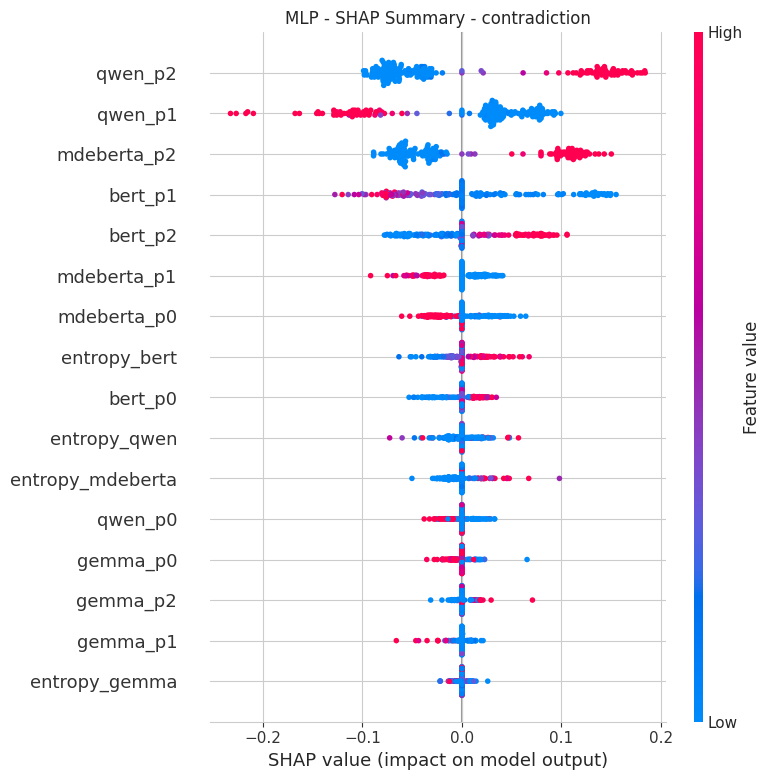

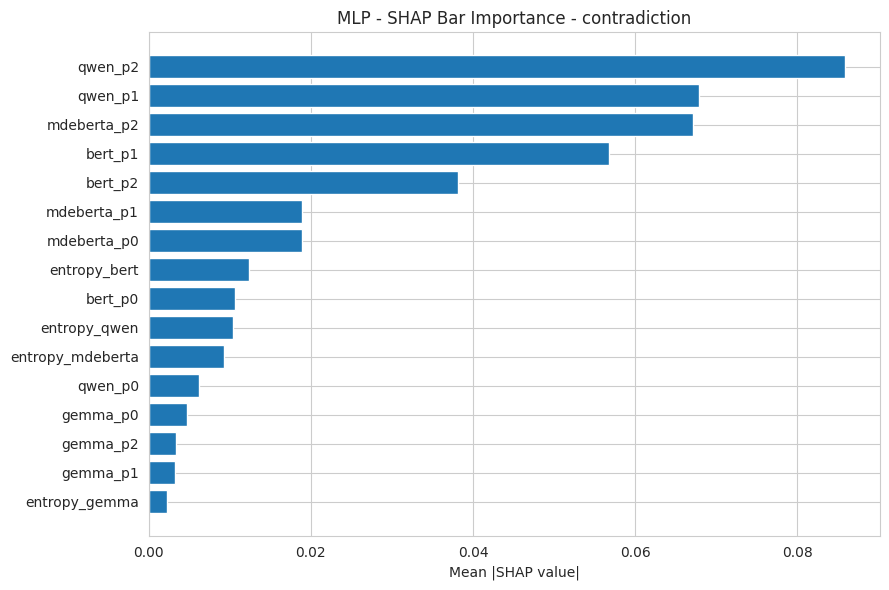

**MLP / contradiction:** Top rows/bars indicate the features most influential for this class. For contradiction, inspect whether qwen/gemma probabilities and entropy features dominate.

In [16]:
explainer_mlp, shap_vals_mlp = run_shap_multiclass(
    model_name="MLP",
    predict_fn=predict_mlp_proba,
    X_background=X_bg_kernel,
    X_to_explain=X_exp,
    nsamples=KERNEL_NSAMPLES_MLP,
)



Running SHAP for LinearSVC


  0%|          | 0/120 [00:00<?, ?it/s]

/tmp/ipykernel_1588/768332465.py:13: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(sv, X_to_explain, feature_names=FEATURE_NAMES, show=False, plot_type="dot")


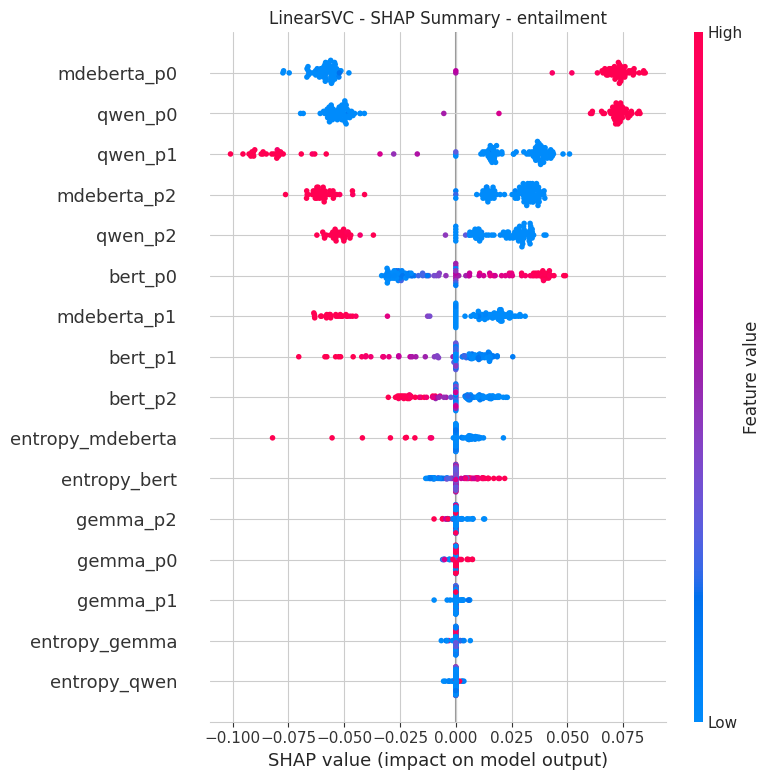

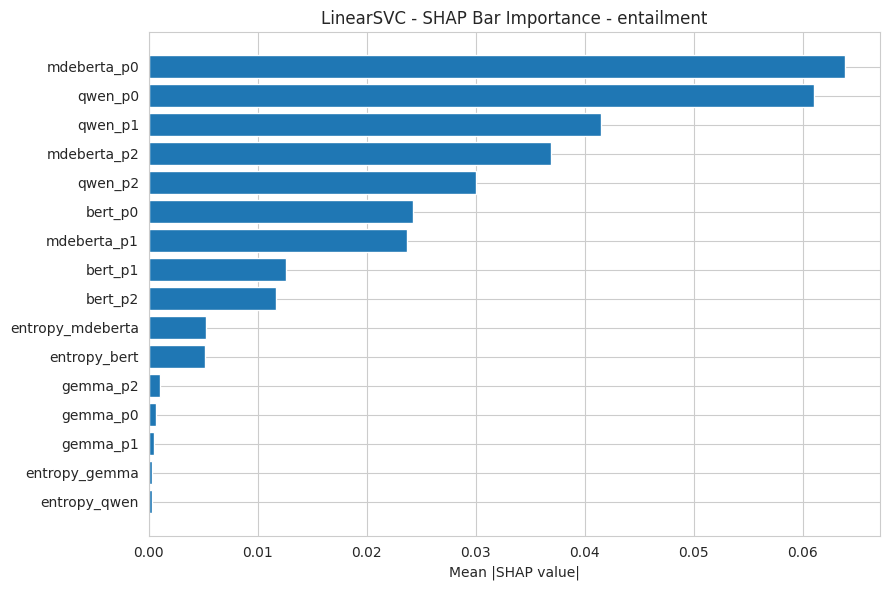

**LinearSVC / entailment:** Top rows/bars indicate the features most influential for this class. For contradiction, inspect whether qwen/gemma probabilities and entropy features dominate.

/tmp/ipykernel_1588/768332465.py:13: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(sv, X_to_explain, feature_names=FEATURE_NAMES, show=False, plot_type="dot")


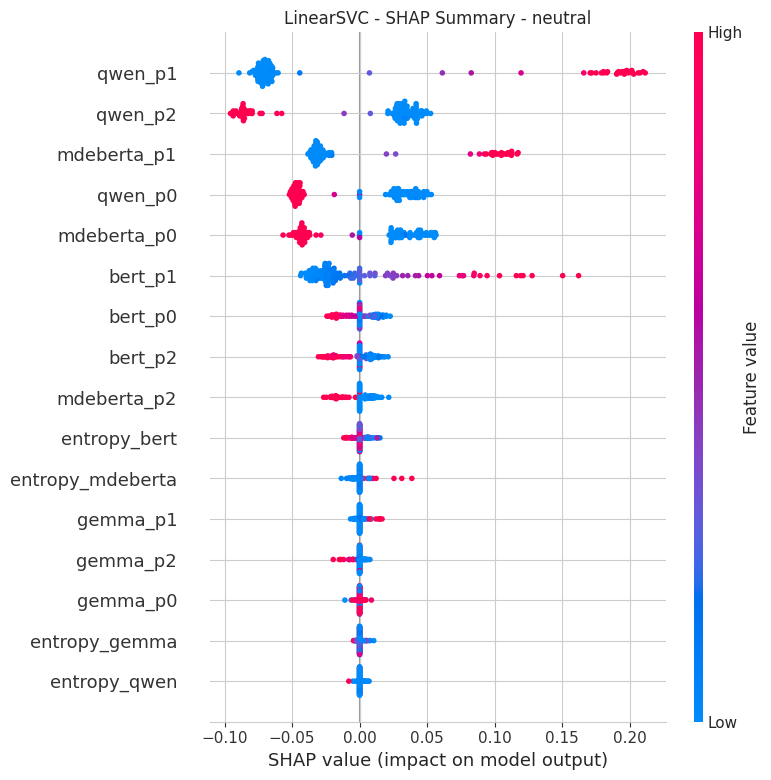

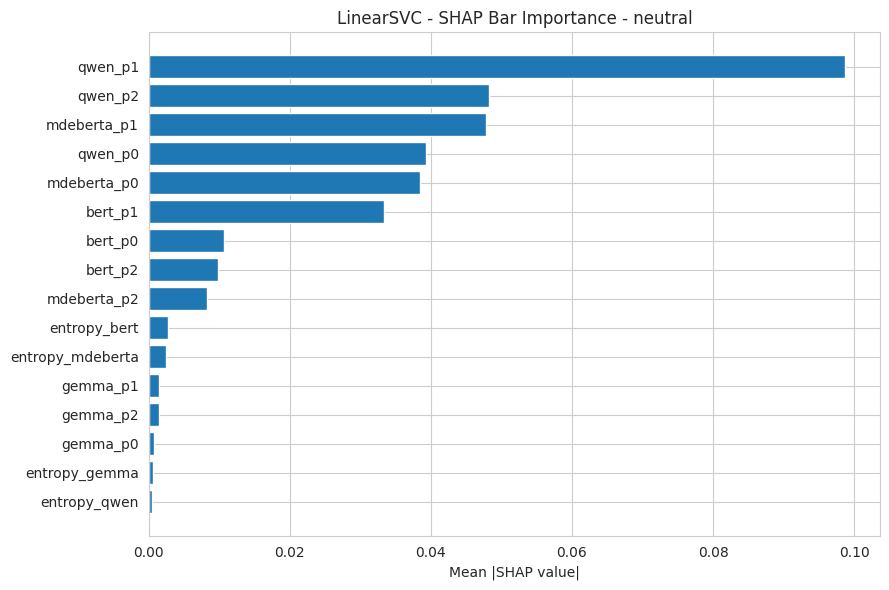

**LinearSVC / neutral:** Top rows/bars indicate the features most influential for this class. For contradiction, inspect whether qwen/gemma probabilities and entropy features dominate.

/tmp/ipykernel_1588/768332465.py:13: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(sv, X_to_explain, feature_names=FEATURE_NAMES, show=False, plot_type="dot")


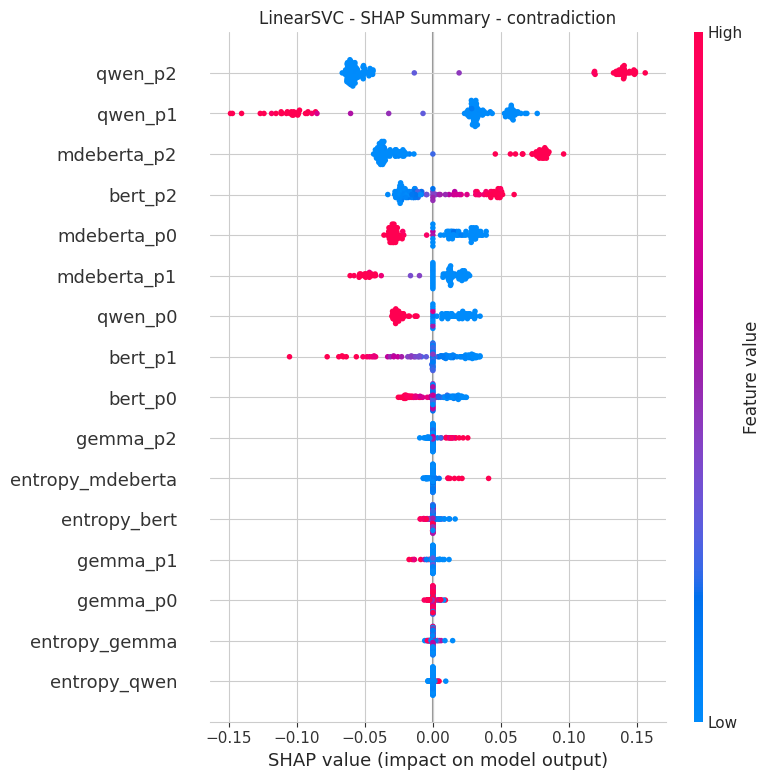

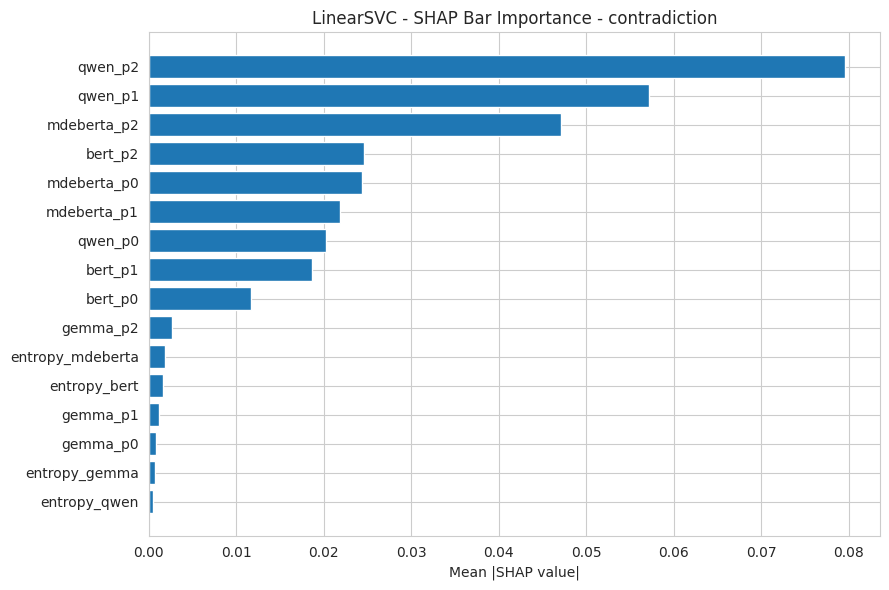

**LinearSVC / contradiction:** Top rows/bars indicate the features most influential for this class. For contradiction, inspect whether qwen/gemma probabilities and entropy features dominate.


Running SHAP for BiLSTM


  0%|          | 0/120 [00:00<?, ?it/s]

/tmp/ipykernel_1588/768332465.py:13: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(sv, X_to_explain, feature_names=FEATURE_NAMES, show=False, plot_type="dot")


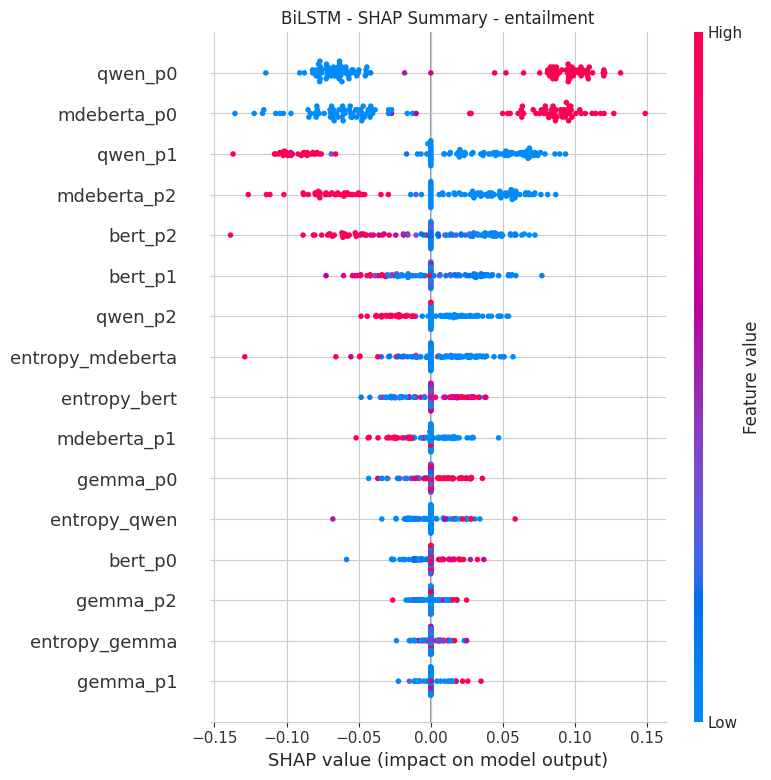

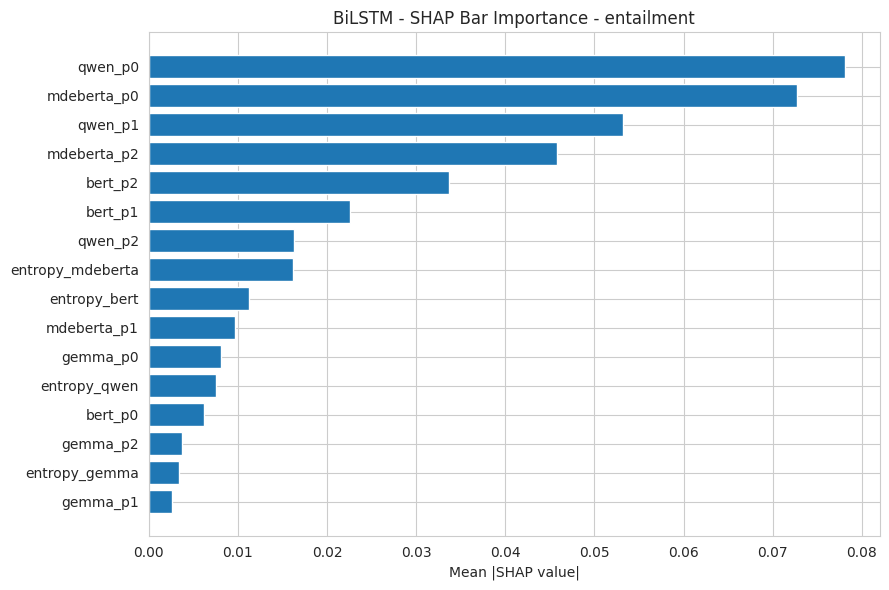

**BiLSTM / entailment:** Top rows/bars indicate the features most influential for this class. For contradiction, inspect whether qwen/gemma probabilities and entropy features dominate.

/tmp/ipykernel_1588/768332465.py:13: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(sv, X_to_explain, feature_names=FEATURE_NAMES, show=False, plot_type="dot")


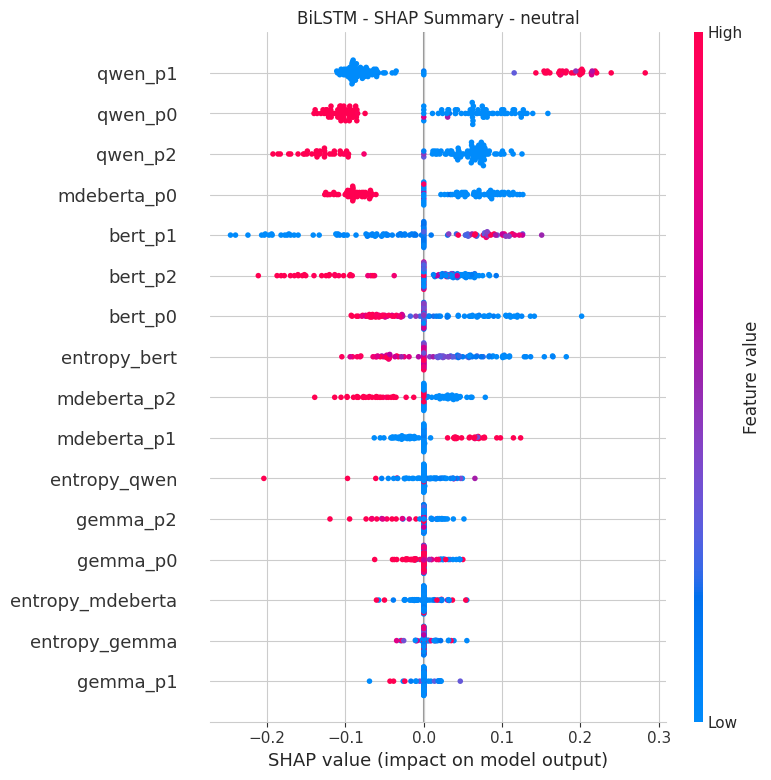

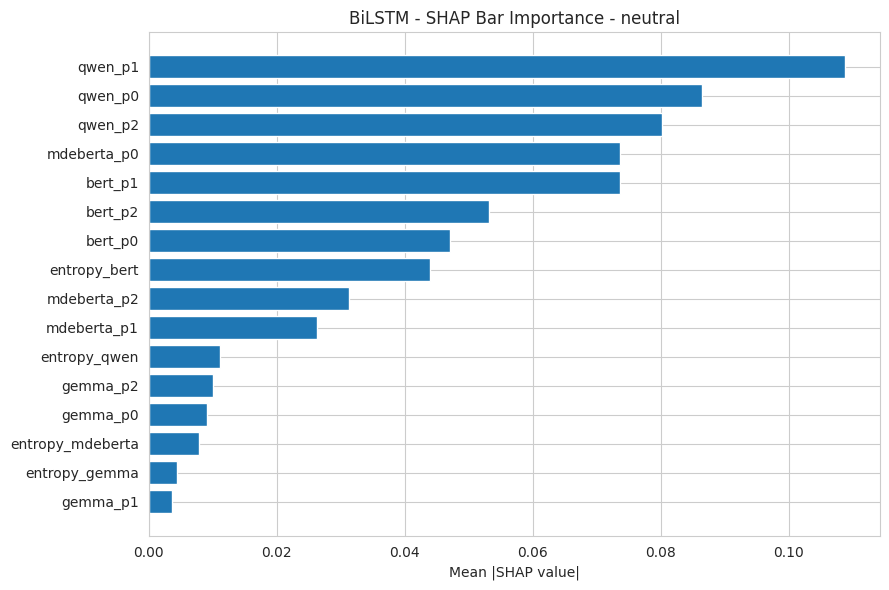

**BiLSTM / neutral:** Top rows/bars indicate the features most influential for this class. For contradiction, inspect whether qwen/gemma probabilities and entropy features dominate.

/tmp/ipykernel_1588/768332465.py:13: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(sv, X_to_explain, feature_names=FEATURE_NAMES, show=False, plot_type="dot")


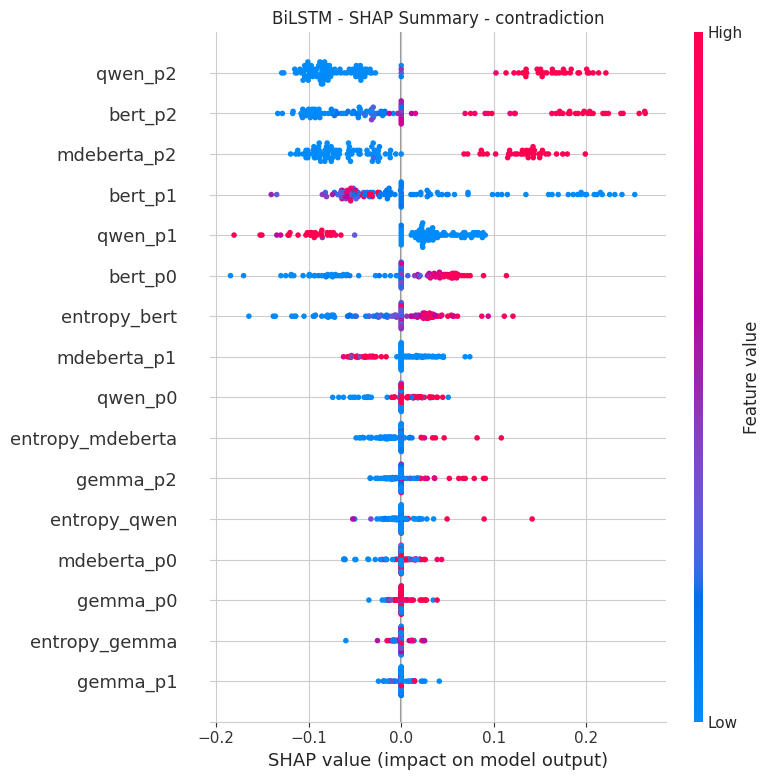

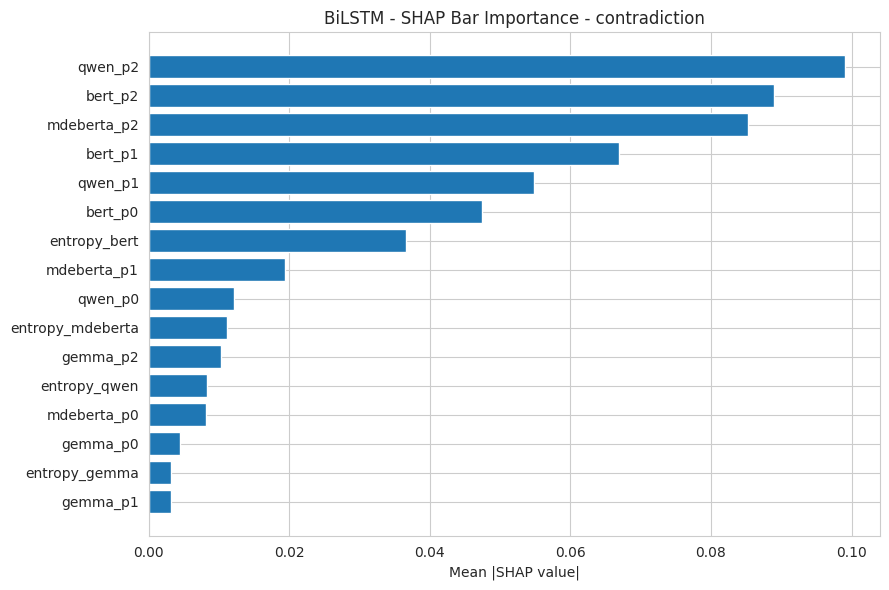

**BiLSTM / contradiction:** Top rows/bars indicate the features most influential for this class. For contradiction, inspect whether qwen/gemma probabilities and entropy features dominate.

In [17]:
X_exp_small = X_exp[: min(N_EXPLAIN_SVM_BILSTM, len(X_exp))]

explainer_svm, shap_vals_svm = run_shap_multiclass(
    model_name="LinearSVC",
    predict_fn=predict_svm_proba,
    X_background=X_bg_kernel,
    X_to_explain=X_exp_small,
    nsamples=KERNEL_NSAMPLES_OTHER,
)

explainer_bilstm, shap_vals_bilstm = run_shap_multiclass(
    model_name="BiLSTM",
    predict_fn=predict_bilstm_proba,
    X_background=X_bg_kernel,
    X_to_explain=X_exp_small,
    nsamples=KERNEL_NSAMPLES_OTHER,
)


### Contradiction-focused quick summary

Contradiction is often the weakest class, so we inspect class index `2` specifically.
The next cell builds a compact top-feature table for contradiction from MLP SHAP values.


In [18]:
contr_idx = 2
sv_contr = shap_vals_mlp[contr_idx] if isinstance(shap_vals_mlp, list) else shap_vals_mlp[:, :, contr_idx]

contr_df = pd.DataFrame({
    "feature": FEATURE_NAMES,
    "mean_abs_shap": np.abs(sv_contr).mean(axis=0),
}).sort_values("mean_abs_shap", ascending=False)

display(contr_df.head(10))
out_csv = PLOTS_DIR / "mlp_contradiction_top_features.csv"
contr_df.to_csv(out_csv, index=False)
print("Saved contradiction feature ranking:", out_csv)


,feature,mean_abs_shap
11,qwen_p2,0.085895
10,qwen_p1,0.067889
5,mdeberta_p2,0.067181
1,bert_p1,0.056732
2,bert_p2,0.038202
4,mdeberta_p1,0.018894
3,mdeberta_p0,0.018848
12,entropy_bert,0.012374
0,bert_p0,0.010633
15,entropy_qwen,0.010348


Saved contradiction feature ranking: xai_plots/mlp_contradiction_top_features.csv


## Individual Example Explanations (SHAP force + waterfall)

We pick 4 diverse examples:
- one correct entailment (if available)
- one correct contradiction (if available)
- one wrong contradiction (if available)
- one additional fallback

Then we save force and waterfall plots with clear filenames.


In [19]:
example_pool = []

def add_first(mask, tag):
    idx = np.where(mask)[0]
    if len(idx):
        example_pool.append((int(idx[0]), tag))

add_first((y_exp == 0) & (pred_mlp == 0), "entailment_correct")
add_first((y_exp == 2) & (pred_mlp == 2), "contradiction_correct")
add_first((y_exp == 2) & (pred_mlp != 2), "contradiction_error")
add_first((pred_mlp != y_exp), "generic_error")

used = {i for i, _ in example_pool}
for i in range(len(X_exp)):
    if i not in used:
        example_pool.append((int(i), f"fallback_{len(example_pool)}"))
        used.add(i)
    if len(example_pool) >= 4:
        break

example_pool = example_pool[:4]
print("Selected examples:", example_pool)


Selected examples: [(8, 'entailment_correct'), (4, 'contradiction_correct'), (2, 'contradiction_error'), (1, 'generic_error')]


<Figure size 1400x300 with 0 Axes>

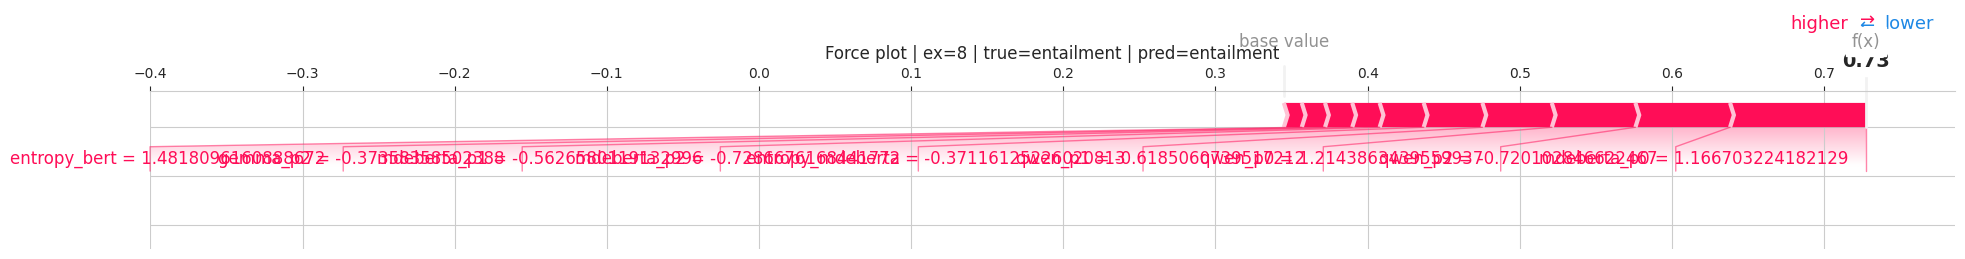

Saved: xai_plots/force_example_entailment_correct.png


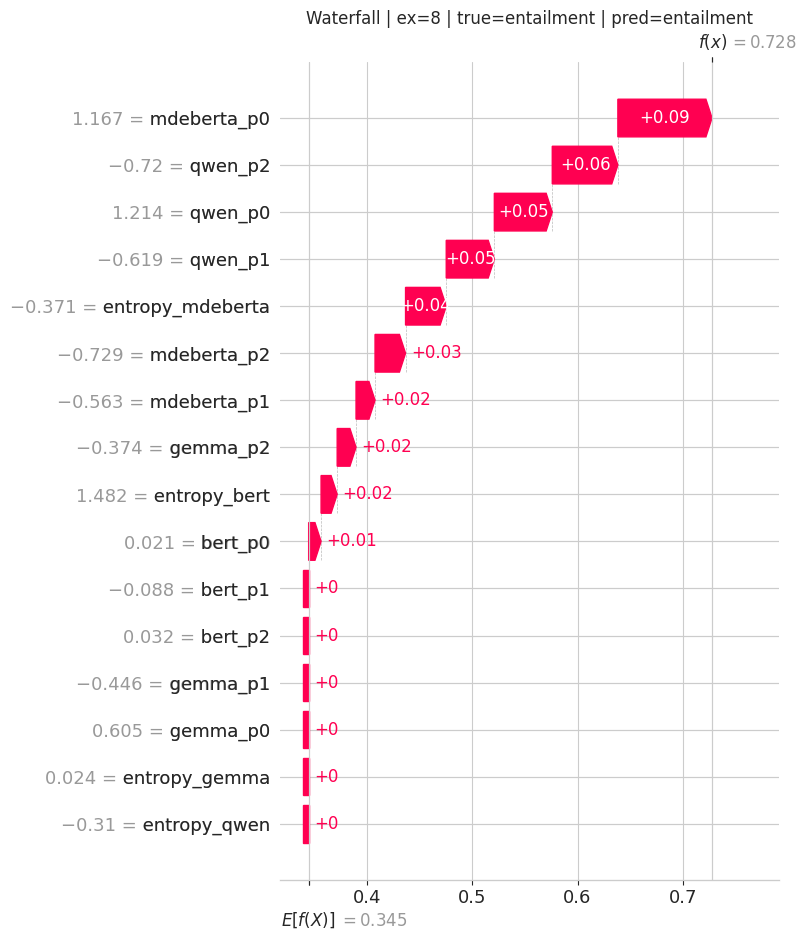

Saved: xai_plots/waterfall_example_entailment_correct.png


<Figure size 1400x300 with 0 Axes>

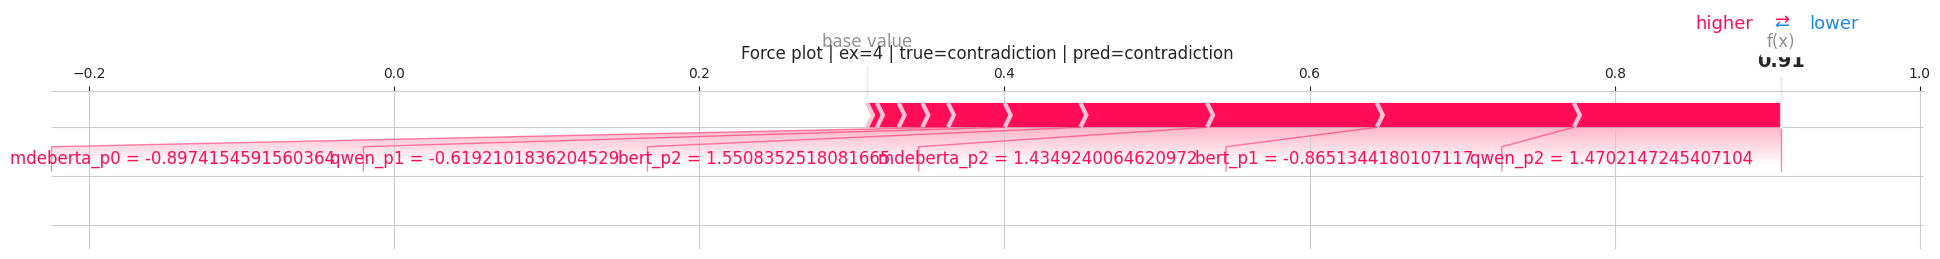

Saved: xai_plots/force_example_contradiction_correct.png


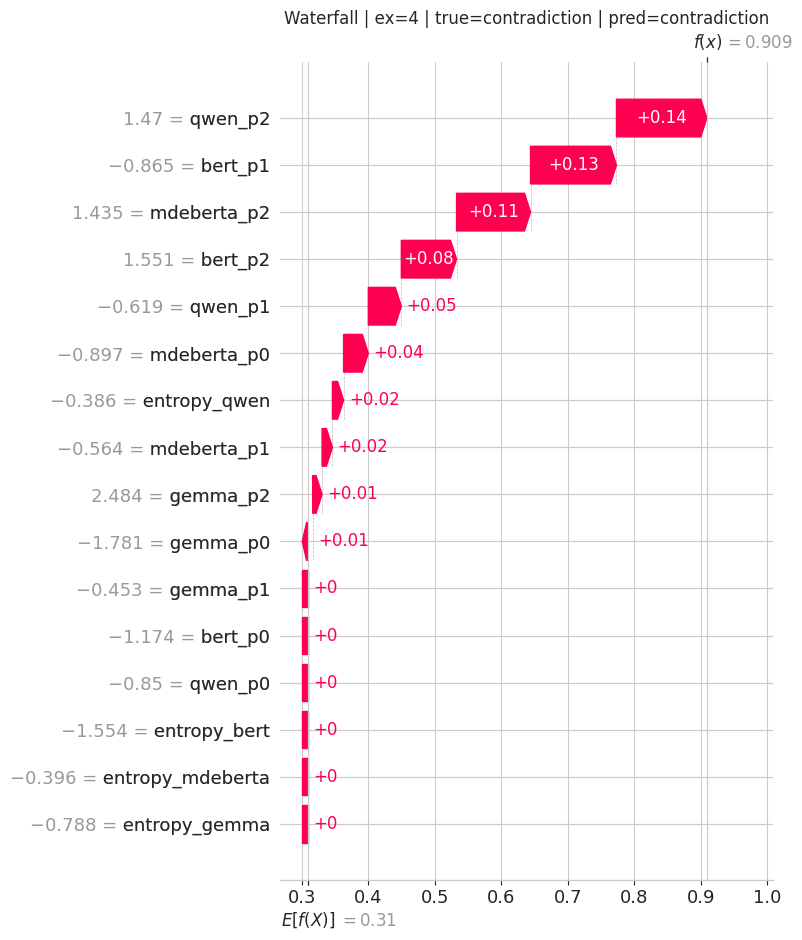

Saved: xai_plots/waterfall_example_contradiction_correct.png


<Figure size 1400x300 with 0 Axes>

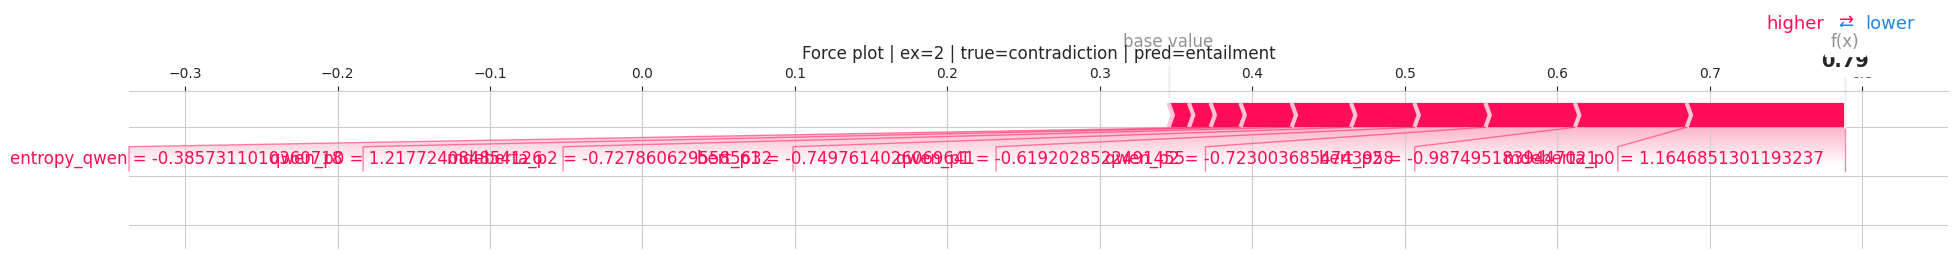

Saved: xai_plots/force_example_contradiction_error.png


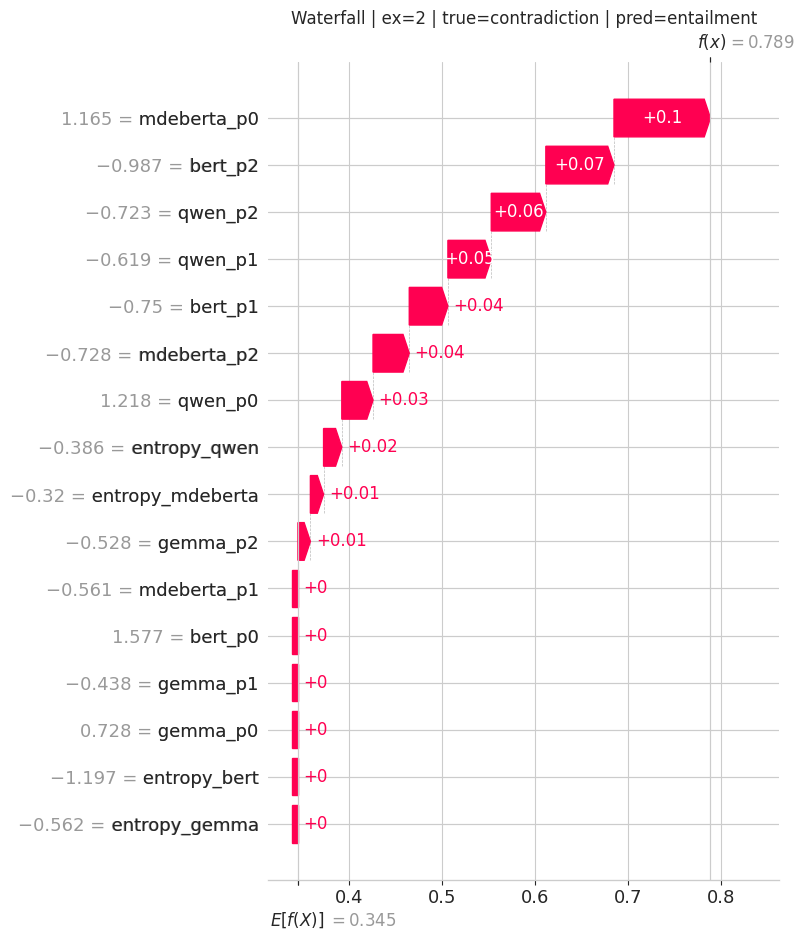

Saved: xai_plots/waterfall_example_contradiction_error.png


<Figure size 1400x300 with 0 Axes>

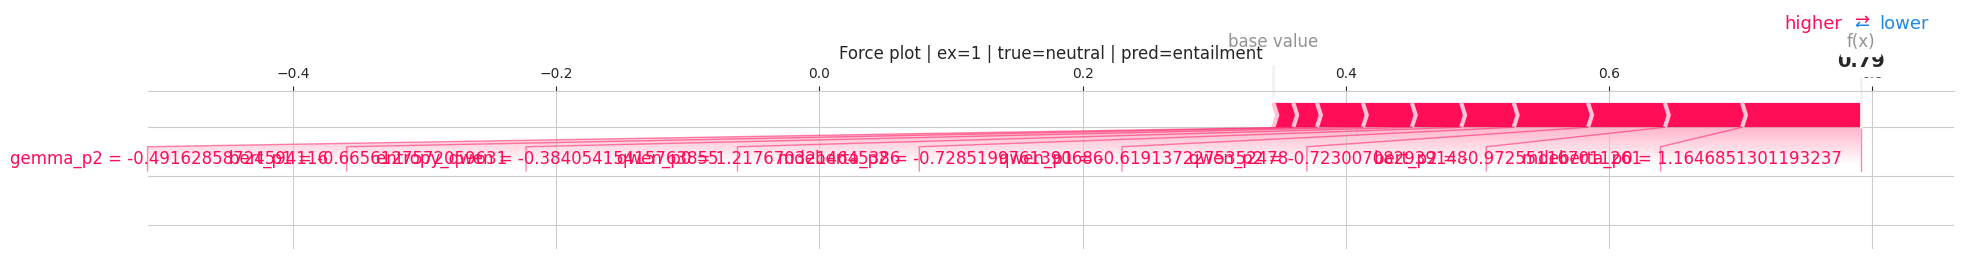

Saved: xai_plots/force_example_generic_error.png


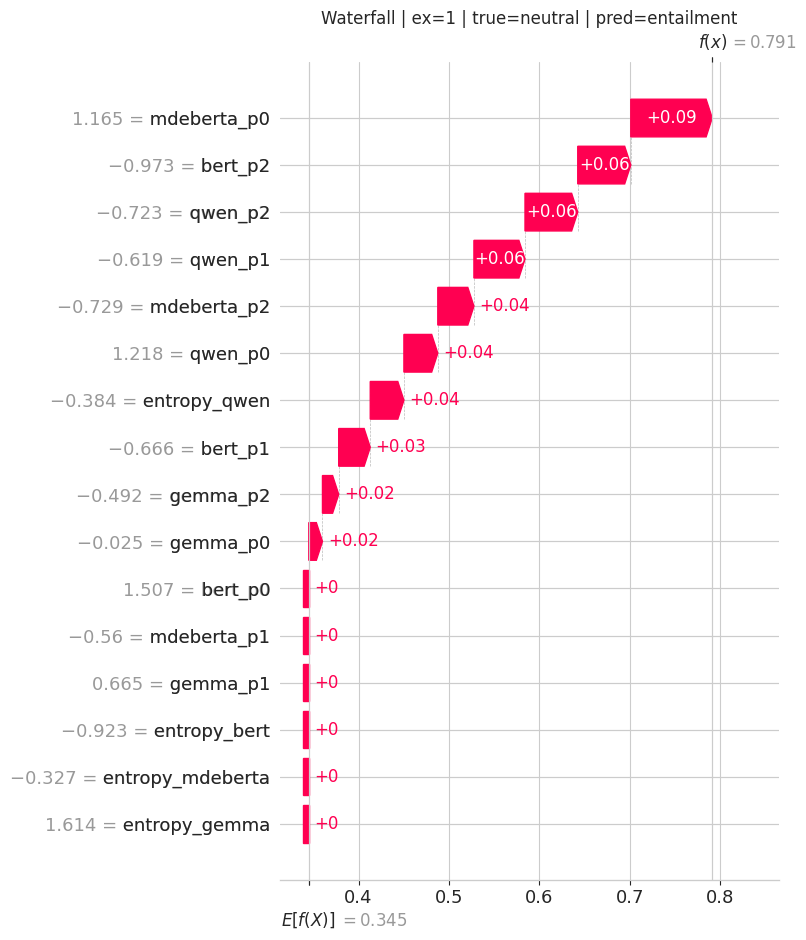

Saved: xai_plots/waterfall_example_generic_error.png


In [20]:
def save_force_plot_for_example(idx, tag):
    pred_cls = int(pred_mlp[idx])
    true_cls = int(y_exp[idx])

    sv = shap_vals_mlp[pred_cls][idx] if isinstance(shap_vals_mlp, list) else shap_vals_mlp[idx, :, pred_cls]
    base = explainer_mlp.expected_value[pred_cls] if isinstance(explainer_mlp.expected_value, (list, np.ndarray)) else explainer_mlp.expected_value

    plt.figure(figsize=(14, 3))
    shap.force_plot(base, sv, X_exp[idx], feature_names=FEATURE_NAMES, matplotlib=True, show=False)
    plt.title(f"Force plot | ex={idx} | true={LABEL_NAMES[true_cls]} | pred={LABEL_NAMES[pred_cls]}")
    plt.tight_layout()
    out_path = PLOTS_DIR / f"force_example_{tag}.png"
    plt.savefig(out_path, dpi=SAVE_DPI, bbox_inches="tight")
    plt.show()
    print("Saved:", out_path)


def save_waterfall_plot_for_example(idx, tag):
    pred_cls = int(pred_mlp[idx])
    true_cls = int(y_exp[idx])

    sv = shap_vals_mlp[pred_cls][idx] if isinstance(shap_vals_mlp, list) else shap_vals_mlp[idx, :, pred_cls]
    base = explainer_mlp.expected_value[pred_cls] if isinstance(explainer_mlp.expected_value, (list, np.ndarray)) else explainer_mlp.expected_value

    exp_obj = shap.Explanation(values=sv, base_values=base, data=X_exp[idx], feature_names=FEATURE_NAMES)

    plt.figure(figsize=(10, 6))
    shap.plots.waterfall(exp_obj, max_display=16, show=False)
    plt.title(f"Waterfall | ex={idx} | true={LABEL_NAMES[true_cls]} | pred={LABEL_NAMES[pred_cls]}")
    plt.tight_layout()
    out_path = PLOTS_DIR / f"waterfall_example_{tag}.png"
    plt.savefig(out_path, dpi=SAVE_DPI, bbox_inches="tight")
    plt.show()
    print("Saved:", out_path)


for idx, tag in example_pool:
    save_force_plot_for_example(idx, tag)
    save_waterfall_plot_for_example(idx, tag)

if torch.cuda.is_available():
    torch.cuda.empty_cache()


## LIME Explanations (recommended comparison)

We explain 3-4 examples with `LimeTabularExplainer`.
This gives another local perspective for comparison with SHAP.


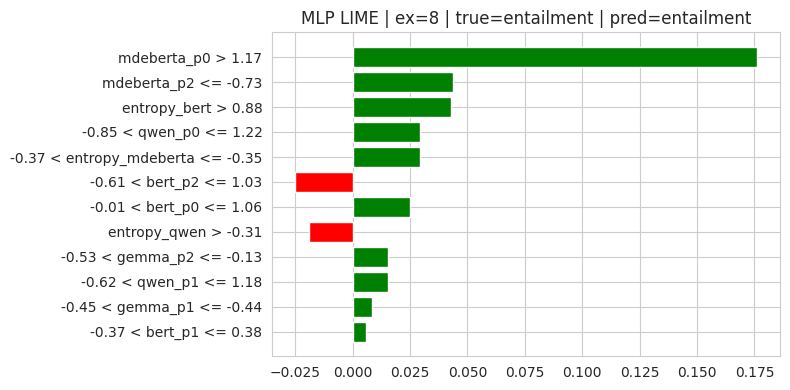

Saved: xai_plots/lime_mlp_entailment_correct.png


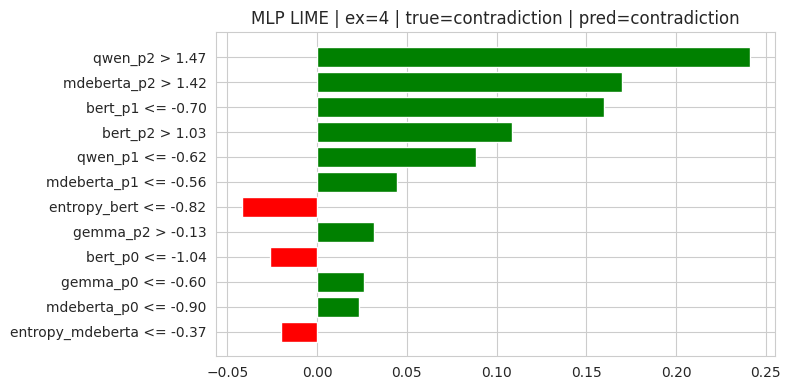

Saved: xai_plots/lime_mlp_contradiction_correct.png


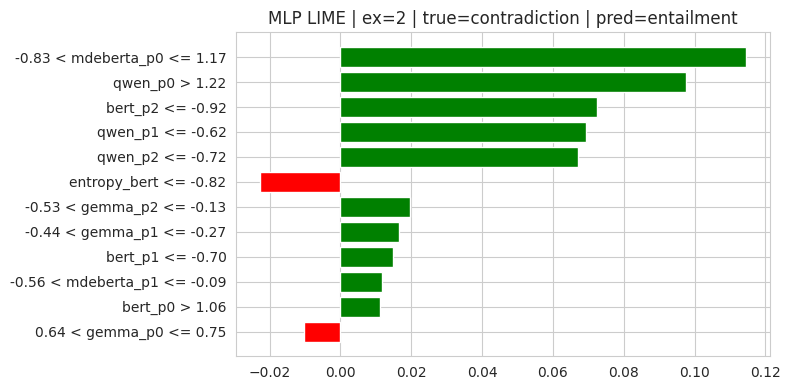

Saved: xai_plots/lime_mlp_contradiction_error.png


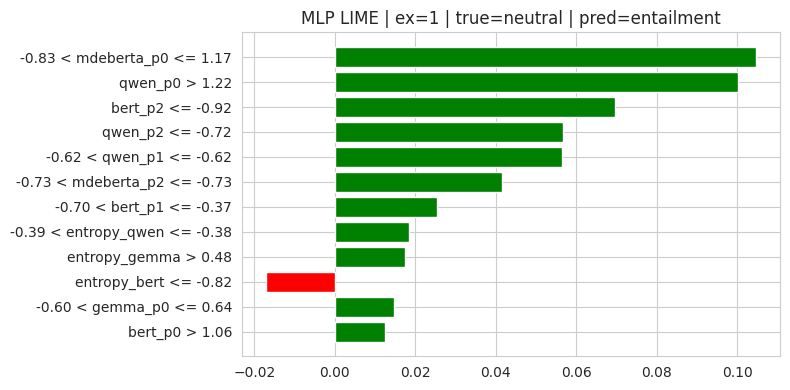

Saved: xai_plots/lime_mlp_generic_error.png


In [21]:
lime_explainer = LimeTabularExplainer(
    training_data=X_bg,
    feature_names=FEATURE_NAMES,
    class_names=LABEL_NAMES,
    mode="classification",
    discretize_continuous=True,
    random_state=SEED,
)


def save_lime_examples(predict_fn, model_name, example_list):
    for idx, tag in example_list:
        x_i = X_exp[idx]
        pred_cls = int(np.argmax(predict_fn(x_i.reshape(1, -1))[0]))
        true_cls = int(y_exp[idx])

        exp = lime_explainer.explain_instance(
            data_row=x_i,
            predict_fn=predict_fn,
            num_features=12,
            top_labels=1,
        )

        fig = exp.as_pyplot_figure(label=pred_cls)
        fig.set_size_inches(8, 4)
        plt.title(f"{model_name} LIME | ex={idx} | true={LABEL_NAMES[true_cls]} | pred={LABEL_NAMES[pred_cls]}")
        plt.tight_layout()

        out_path = PLOTS_DIR / f"lime_{model_name.lower()}_{tag}.png"
        plt.savefig(out_path, dpi=SAVE_DPI, bbox_inches="tight")
        plt.show()
        print("Saved:", out_path)


save_lime_examples(predict_mlp_proba, "MLP", example_pool[:4])


## Key Insights from XAI

Use this section to write your final observations for your report.

### Suggested prompts

1. Which features are most influential for **contradiction**?
   - e.g., `qwen_p2`, `gemma_p2`, `entropy_gemma`
2. Does entropy actually help the model?
   - Compare entropy ranks vs probability ranks.
3. How do explanations differ across classes?
4. Is the ensemble over-relying on one base model?
5. For error cases, which features push predictions in the wrong direction?


,class,block,mean_abs_shap,relative
0,entailment,bert,0.063869,0.167764
1,entailment,mdeberta,0.153252,0.402549
2,entailment,gemma,0.012846,0.033743
3,entailment,qwen,0.150738,0.395945
4,neutral,bert,0.103950,0.226163
5,neutral,mdeberta,0.132211,0.287650
6,neutral,gemma,0.014008,0.030477
7,neutral,qwen,0.209456,0.455710
8,contradiction,bert,0.117939,0.283343
9,contradiction,mdeberta,0.114253,0.274487


Saved: xai_plots/mlp_block_level_importance.csv


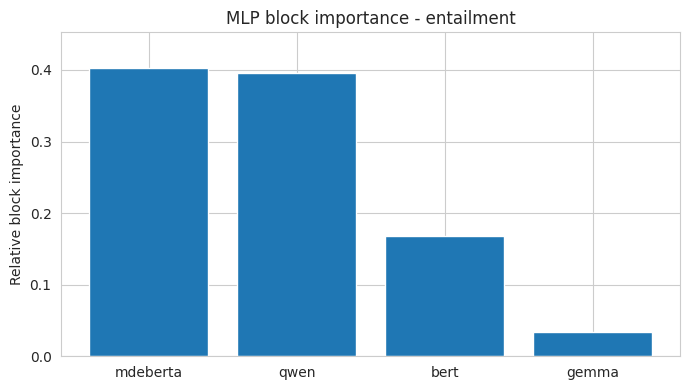

Saved: xai_plots/mlp_block_importance_entailment.png


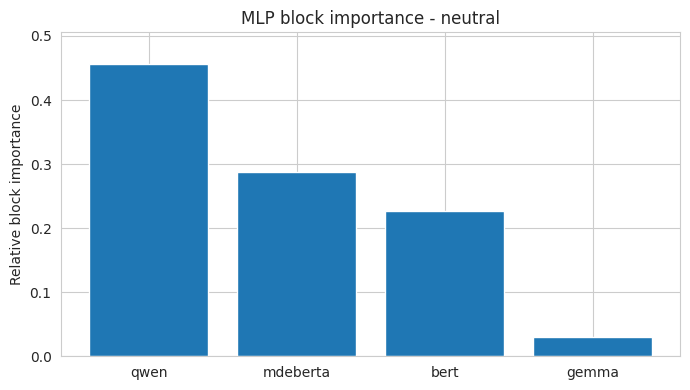

Saved: xai_plots/mlp_block_importance_neutral.png


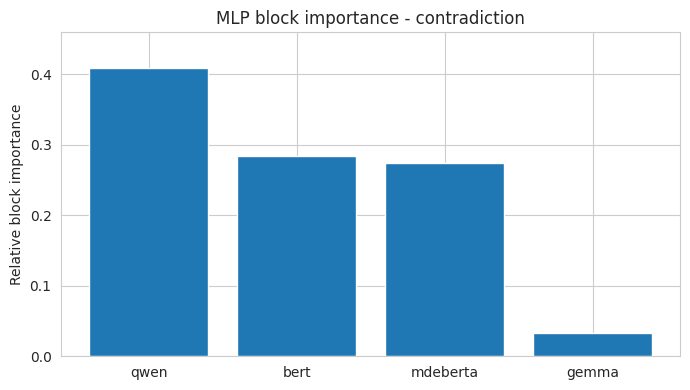

Saved: xai_plots/mlp_block_importance_contradiction.png


In [22]:
block_map = {
    "bert": [0, 1, 2, 12],
    "mdeberta": [3, 4, 5, 13],
    "gemma": [6, 7, 8, 14],
    "qwen": [9, 10, 11, 15],
}

rows = []
for class_idx, class_name in enumerate(LABEL_NAMES):
    sv = shap_vals_mlp[class_idx] if isinstance(shap_vals_mlp, list) else shap_vals_mlp[:, :, class_idx]
    mean_abs = np.abs(sv).mean(axis=0)

    total = 0.0
    block_vals = {}
    for block, cols in block_map.items():
        val = float(mean_abs[cols].sum())
        block_vals[block] = val
        total += val

    for block, val in block_vals.items():
        rows.append({
            "class": class_name,
            "block": block,
            "mean_abs_shap": val,
            "relative": val / (total + 1e-12),
        })

block_df = pd.DataFrame(rows)
display(block_df)

out_csv = PLOTS_DIR / "mlp_block_level_importance.csv"
block_df.to_csv(out_csv, index=False)
print("Saved:", out_csv)

for class_name in LABEL_NAMES:
    dd = block_df[block_df["class"] == class_name].sort_values("relative", ascending=False)
    plt.figure(figsize=(7, 4))
    plt.bar(dd["block"], dd["relative"])
    plt.ylim(0, max(0.4, dd["relative"].max() + 0.05))
    plt.ylabel("Relative block importance")
    plt.title(f"MLP block importance - {class_name}")
    plt.tight_layout()
    out_path = PLOTS_DIR / f"mlp_block_importance_{class_name}.png"
    plt.savefig(out_path, dpi=SAVE_DPI, bbox_inches="tight")
    plt.show()
    print("Saved:", out_path)


## Completion checklist

- [x] Beginner-friendly explanations
- [x] SHAP loop over all 3 classes
- [x] Contradiction-focused summaries
- [x] Force + waterfall local examples
- [x] LIME comparison examples
- [x] High-quality (300 dpi) saved plots in `xai_plots/`
- [x] T4-friendly runtime defaults
